# 04 Hybrid RGB-FFT Fusion Model

## CSE 445: Machine Learning Project

**Project Title:** Robust AI-Generated Image Detection using Hybrid Spatial–Frequency Analysis  
**Student:** Zawed Bin Tariq  
**Student ID:** 2232811642  
**Instructor:** Dr. Mohammad Abdul Qayum  

---

## Notebook Objective

This notebook implements a hybrid spatial-frequency fusion model for AI-generated image detection.

Previous experiments showed:

| Model | Input Type | Test Accuracy | F1-score |
|---|---|---:|---:|
| ResNet18 RGB Baseline | RGB spatial images | 87.00% | 87.50% |
| ResNet18 FFT Baseline | FFT magnitude spectra | 65.00% | 67.21% |

The RGB model performed strongly, while the FFT-only model showed severe overfitting.

Therefore, this notebook tests whether FFT information can improve performance when used as a complementary feature stream rather than as a standalone input.

# 1. Paper-Inspired Motivation

Recent research suggests that AI-generated images may contain both spatial-domain artifacts and frequency-domain artifacts.

The FreqCross paper proposes a multi-modal fusion approach using:

1. RGB spatial features
2. 2D FFT magnitude features
3. Radial energy distribution features

Similarly, dual-branch spatial-frequency models process RGB and FFT representations separately and fuse the learned features before classification.

Inspired by these works, this notebook implements a lightweight hybrid fusion model:

- **RGB Branch:** ResNet18 feature extractor
- **FFT Branch:** Lightweight CNN feature extractor
- **Fusion Layer:** Concatenation of RGB and FFT features
- **Classifier:** Fully connected classification head

This is not a full reproduction of FreqCross or the transformer-based paper.  
It is a practical paper-inspired implementation suitable for Kaggle-scale training.

In [1]:
# ============================================================
# 2. Import Required Libraries
# ============================================================

import os
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore", category=UserWarning)

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)

Libraries imported successfully.
PyTorch version: 2.10.0+cu128


In [2]:
# ============================================================
# 3. Device Configuration
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Enable GPU before training.")

Using device: cuda
GPU name: Tesla T4


In [3]:
# ============================================================
# 4. Reproducibility Setup
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed fixed at: {SEED}")

Random seed fixed at: 42


# 2. Dataset Loading and Split

The same balanced dataset strategy is reused:

| Class | Images |
|---|---:|
| Real | 2000 |
| Fake | 2000 |
| **Total** | **4000** |

Split:

| Split | Images |
|---|---:|
| Training | 2400 |
| Validation | 800 |
| Testing | 800 |

Using the same seed keeps the dataset split consistent with previous notebooks.

In [4]:
# ============================================================
# 5. Load Image Paths - Fast Version
# ============================================================

dataset_root = Path("/kaggle/input/datasets/tristanzhang32/ai-generated-images-vs-real-images")

image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

real_paths = []
fake_paths = []

for split_folder in ["train", "test"]:
    real_dir = dataset_root / split_folder / "real"
    fake_dir = dataset_root / split_folder / "fake"
    
    real_paths.extend([
        p for p in real_dir.iterdir()
        if p.suffix.lower() in image_extensions
    ])
    
    fake_paths.extend([
        p for p in fake_dir.iterdir()
        if p.suffix.lower() in image_extensions
    ])

all_image_paths = real_paths + fake_paths

print(f"Total image files found: {len(all_image_paths)}")
print(f"Real images found: {len(real_paths)}")
print(f"Fake images found: {len(fake_paths)}")

Total image files found: 60000
Real images found: 30000
Fake images found: 30000


In [7]:
# ============================================================
# 6. Balanced Sampling: 2000 Real + 2000 Fake
# ============================================================

N_REAL = 2000
N_FAKE = 2000

real_sample = random.sample(real_paths, N_REAL)
fake_sample = random.sample(fake_paths, N_FAKE)

real_df = pd.DataFrame({
    "image_path": [str(p) for p in real_sample],
    "label": 0,
    "class_name": "real"
})

fake_df = pd.DataFrame({
    "image_path": [str(p) for p in fake_sample],
    "label": 1,
    "class_name": "fake"
})

df = pd.concat([real_df, fake_df], ignore_index=True)
df = shuffle(df, random_state=SEED).reset_index(drop=True)

print("Balanced dataframe created.")
print(df["class_name"].value_counts())

Balanced dataframe created.
class_name
real    2000
fake    2000
Name: count, dtype: int64


In [8]:
# ============================================================
# 7. Train/Validation/Test Split
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.40,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Dataset split completed.")

print("\nTrain size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nClass distribution:")
print("Train:")
print(train_df["class_name"].value_counts())
print("\nValidation:")
print(val_df["class_name"].value_counts())
print("\nTest:")
print(test_df["class_name"].value_counts())

Dataset split completed.

Train size: 2400
Validation size: 800
Test size: 800

Class distribution:
Train:
class_name
real    1200
fake    1200
Name: count, dtype: int64

Validation:
class_name
real    400
fake    400
Name: count, dtype: int64

Test:
class_name
real    400
fake    400
Name: count, dtype: int64


# 3. FFT Transformation

For each image, the hybrid model receives two inputs:

1. The original RGB image
2. The FFT magnitude spectrum image

The FFT image is generated from the grayscale image using:

- 2D FFT
- Center shift
- Log magnitude transform
- Min-max normalization
- Conversion to 3-channel RGB format

In [9]:
# ============================================================
# 8. FFT Magnitude Spectrum Function
# ============================================================

def image_to_fft_pil(image_path, image_size=(224, 224)):
    image = Image.open(image_path).convert("L")
    image = image.resize(image_size)
    
    image_array = np.array(image)
    
    fft = np.fft.fft2(image_array)
    fft_shift = np.fft.fftshift(fft)
    magnitude = np.log1p(np.abs(fft_shift))
    
    magnitude = magnitude - magnitude.min()
    magnitude = magnitude / (magnitude.max() + 1e-8)
    magnitude = (magnitude * 255).astype(np.uint8)
    
    fft_image = Image.fromarray(magnitude).convert("RGB")
    
    return fft_image

print("FFT transformation function defined successfully.")

FFT transformation function defined successfully.


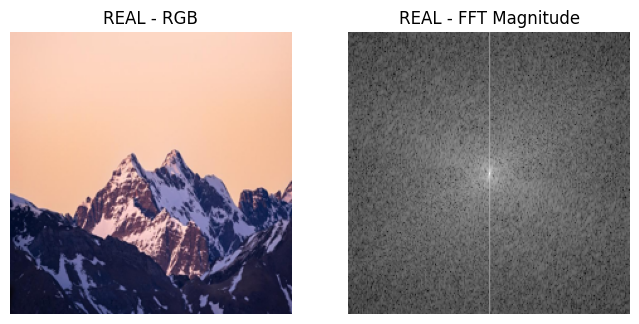

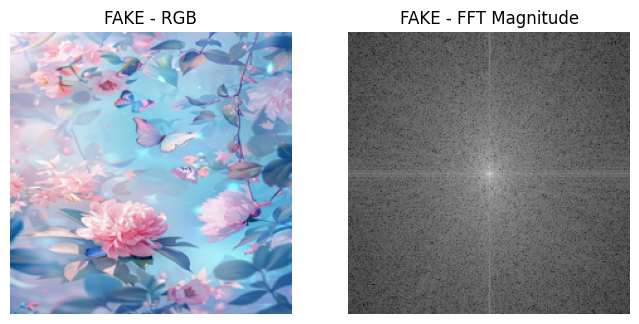

In [10]:
# ============================================================
# 9. Visual Sanity Check: RGB and FFT Inputs
# ============================================================

def show_rgb_fft_pair(dataframe, class_name):
    sample = dataframe[dataframe["class_name"] == class_name].sample(n=1, random_state=SEED).iloc[0]
    image_path = sample["image_path"]
    
    rgb_image = Image.open(image_path).convert("RGB").resize((224, 224))
    fft_image = image_to_fft_pil(image_path)
    
    plt.figure(figsize=(8, 4))
    
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_image)
    plt.title(f"{class_name.upper()} - RGB")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(fft_image)
    plt.title(f"{class_name.upper()} - FFT Magnitude")
    plt.axis("off")
    
    plt.show()

show_rgb_fft_pair(train_df, "real")
show_rgb_fft_pair(train_df, "fake")

# 4. Hybrid Dataset Class

The custom dataset returns three items for each sample:

1. RGB image tensor
2. FFT image tensor
3. Class label

This allows the model to learn from spatial and frequency representations simultaneously.

In [11]:
# ============================================================
# 10. Image Transformations
# ============================================================

IMG_SIZE = 224

rgb_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

rgb_eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

fft_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("RGB and FFT transformations defined.")

RGB and FFT transformations defined.


In [12]:
# ============================================================
# 11. Hybrid RGB-FFT Dataset Class
# ============================================================

class HybridRGBFFTDataset(Dataset):
    def __init__(self, dataframe, rgb_transform=None, fft_transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.rgb_transform = rgb_transform
        self.fft_transform = fft_transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = self.dataframe.loc[idx, "image_path"]
        label = int(self.dataframe.loc[idx, "label"])
        
        rgb_image = Image.open(image_path).convert("RGB")
        fft_image = image_to_fft_pil(image_path)
        
        if self.rgb_transform is not None:
            rgb_image = self.rgb_transform(rgb_image)
        
        if self.fft_transform is not None:
            fft_image = self.fft_transform(fft_image)
        
        return rgb_image, fft_image, label

print("Hybrid RGB-FFT Dataset class created.")

Hybrid RGB-FFT Dataset class created.


In [13]:
# ============================================================
# 12. Create Hybrid DataLoaders
# ============================================================

BATCH_SIZE = 32

train_dataset = HybridRGBFFTDataset(
    train_df,
    rgb_transform=rgb_train_transform,
    fft_transform=fft_transform
)

val_dataset = HybridRGBFFTDataset(
    val_df,
    rgb_transform=rgb_eval_transform,
    fft_transform=fft_transform
)

test_dataset = HybridRGBFFTDataset(
    test_df,
    rgb_transform=rgb_eval_transform,
    fft_transform=fft_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Hybrid DataLoaders created successfully.")
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Hybrid DataLoaders created successfully.
Training batches: 75
Validation batches: 25
Testing batches: 25


In [14]:
# ============================================================
# 13. Hybrid DataLoader Sanity Check
# ============================================================

rgb_images, fft_images, labels = next(iter(train_loader))

print("RGB batch shape:", rgb_images.shape)
print("FFT batch shape:", fft_images.shape)
print("Label batch shape:", labels.shape)
print("Sample labels:", labels[:10].tolist())

RGB batch shape: torch.Size([32, 3, 224, 224])
FFT batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Sample labels: [0, 1, 1, 0, 1, 0, 1, 1, 0, 0]


# 5. Hybrid RGB-FFT Fusion Architecture

The proposed hybrid model contains two parallel branches:

## RGB Branch
A pretrained ResNet18 backbone extracts spatial-domain image features from RGB images.

## FFT Branch
A lightweight CNN extracts frequency-domain features from FFT magnitude spectrum images.

## Fusion
The RGB and FFT feature vectors are concatenated and passed through a fully connected classifier.

This design allows the model to learn complementary information from both visual texture patterns and frequency-domain spectral artifacts.

In [15]:
# ============================================================
# 14. Hybrid RGB-FFT Fusion Model
# ============================================================

class HybridRGBFFTModel(nn.Module):
    def __init__(self, num_classes=2):
        super(HybridRGBFFTModel, self).__init__()
        
        # ----------------------------
        # RGB Branch: ResNet18 Backbone
        # ----------------------------
        self.rgb_backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        rgb_features = self.rgb_backbone.fc.in_features
        
        # Remove final classifier from ResNet18
        self.rgb_backbone.fc = nn.Identity()
        
        # ----------------------------
        # FFT Branch: Lightweight CNN
        # ----------------------------
        self.fft_branch = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 112 x 112
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 56 x 56
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        fft_features = 128
        
        # ----------------------------
        # Fusion Classifier
        # ----------------------------
        self.classifier = nn.Sequential(
            nn.Linear(rgb_features + fft_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, rgb_image, fft_image):
        rgb_features = self.rgb_backbone(rgb_image)
        
        fft_features = self.fft_branch(fft_image)
        fft_features = torch.flatten(fft_features, 1)
        
        fused_features = torch.cat([rgb_features, fft_features], dim=1)
        output = self.classifier(fused_features)
        
        return output


hybrid_model = HybridRGBFFTModel(num_classes=2)
hybrid_model = hybrid_model.to(device)

print("Hybrid RGB-FFT fusion model created successfully.")
print("Model device:", next(hybrid_model.parameters()).device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s] 


Hybrid RGB-FFT fusion model created successfully.
Model device: cuda:0


In [16]:
# ============================================================
# 15. Loss Function and Optimizer
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    hybrid_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Loss function and optimizer defined.")

Loss function and optimizer defined.


# 6. Training and Validation Functions

The hybrid model receives two inputs per sample:

1. RGB image tensor
2. FFT magnitude tensor

The model is trained using cross-entropy loss.  
Validation accuracy is used to select the best checkpoint.

In [17]:
# ============================================================
# 16. Training Function for Hybrid Model
# ============================================================

def train_one_epoch_hybrid(model, dataloader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    for rgb_images, fft_images, labels in dataloader:
        rgb_images = rgb_images.to(device)
        fft_images = fft_images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(rgb_images, fft_images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * labels.size(0)
        
        _, preds = torch.max(outputs, 1)
        correct_predictions += (preds == labels).sum().item()
        total_samples += labels.size(0)
    
    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    
    return epoch_loss, epoch_accuracy

In [21]:
# ============================================================
# 17. Evaluation Function for Hybrid Model
# ============================================================

def evaluate_model_hybrid(model, dataloader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():
        for rgb_images, fft_images, labels in dataloader:
            rgb_images = rgb_images.to(device)
            fft_images = fft_images.to(device)
            labels = labels.to(device)
            
            outputs = model(rgb_images, fft_images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * labels.size(0)
            
            _, preds = torch.max(outputs, 1)
            correct_predictions += (preds == labels).sum().item()
            total_samples += labels.size(0)
            
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(preds.cpu().numpy())
    
    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    
    return epoch_loss, epoch_accuracy, all_labels, all_predictions

# 7. Hybrid Model Training

The hybrid model is trained for 5 epochs.

The goal is to test whether FFT information improves detection when used as a complementary feature stream alongside RGB spatial features.

In [22]:
# ============================================================
# 18. Train Hybrid RGB-FFT Fusion Model
# ============================================================

NUM_EPOCHS = 5

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0
best_model_path = "/kaggle/working/best_hybrid_rgb_fft_fusion_model.pth"

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 30)
    
    train_loss, train_acc = train_one_epoch_hybrid(
        hybrid_model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    
    val_loss, val_acc, _, _ = evaluate_model_hybrid(
        hybrid_model,
        val_loader,
        criterion,
        device
    )
    
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_acc:.4f}")
    
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(hybrid_model.state_dict(), best_model_path)
        print("Best hybrid model saved.")

end_time = time.time()
training_time = end_time - start_time

print("\nTraining completed.")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Training Time: {training_time / 60:.2f} minutes")


Epoch 1/5
------------------------------
Train Loss: 0.4524 | Train Accuracy: 0.7817
Val Loss:   0.3024 | Val Accuracy:   0.8850
Best hybrid model saved.

Epoch 2/5
------------------------------
Train Loss: 0.2905 | Train Accuracy: 0.8812
Val Loss:   0.2973 | Val Accuracy:   0.8788

Epoch 3/5
------------------------------
Train Loss: 0.2041 | Train Accuracy: 0.9204
Val Loss:   0.3626 | Val Accuracy:   0.8500

Epoch 4/5
------------------------------
Train Loss: 0.1248 | Train Accuracy: 0.9542
Val Loss:   0.5736 | Val Accuracy:   0.8187

Epoch 5/5
------------------------------
Train Loss: 0.1062 | Train Accuracy: 0.9642
Val Loss:   0.4147 | Val Accuracy:   0.8688

Training completed.
Best Validation Accuracy: 0.8850
Training Time: 25.60 minutes


# 8. Test Set Evaluation

The best hybrid model checkpoint is loaded and evaluated on the unseen test set.

The purpose of this evaluation is to determine whether combining RGB spatial features and FFT frequency features improves performance over the individual RGB-only and FFT-only baselines.

In [ ]:
# ============================================================
# 19. Load Best Hybrid Model and Evaluate on Test Set
# ============================================================

hybrid_model.load_state_dict(torch.load(best_model_path, map_location=device))
hybrid_model = hybrid_model.to(device)

test_loss, test_acc, test_labels, test_preds = evaluate_model_hybrid(
    hybrid_model,
    test_loader,
    criterion,
    device
)

print("Hybrid test evaluation completed.")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# 9. Classification Metrics

The hybrid model is evaluated using the same metrics as the RGB and FFT baselines:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

This ensures fair comparison across all experiments.

In [33]:
# ============================================================
# 20. Classification Metrics
# ============================================================

test_accuracy = accuracy_score(test_labels, test_preds)
test_precision = precision_score(test_labels, test_preds)
test_recall = recall_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds)

print("Final Hybrid Test Metrics:")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    test_labels,
    test_preds,
    target_names=["Real", "Fake"]
))

Final Hybrid Test Metrics:
Accuracy : 0.8425
Precision: 0.8325
Recall   : 0.8575
F1-score : 0.8448

Classification Report:
              precision    recall  f1-score   support

        Real       0.85      0.83      0.84       400
        Fake       0.83      0.86      0.84       400

    accuracy                           0.84       800
   macro avg       0.84      0.84      0.84       800
weighted avg       0.84      0.84      0.84       800



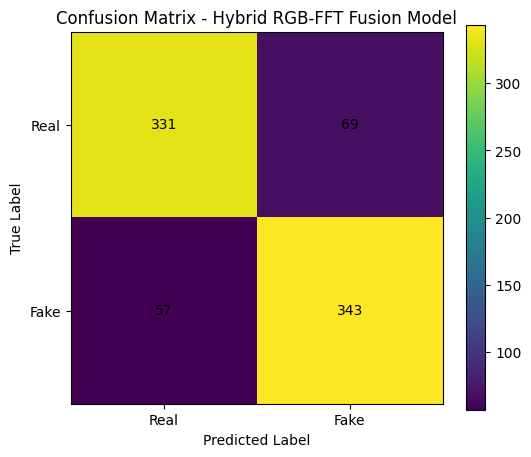

Confusion Matrix:
[[331  69]
 [ 57 343]]


In [30]:
# ============================================================
# 21. Confusion Matrix
# ============================================================

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - Hybrid RGB-FFT Fusion Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Real", "Fake"])
plt.yticks([0, 1], ["Real", "Fake"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

print("Confusion Matrix:")
print(cm)

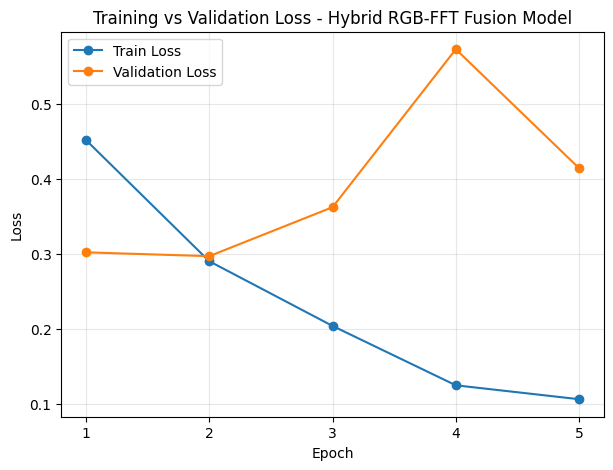

In [35]:
# ============================================================
# 22. Training and Validation Loss Curve
# ============================================================

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.title("Training vs Validation Loss - Hybrid RGB-FFT Fusion Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

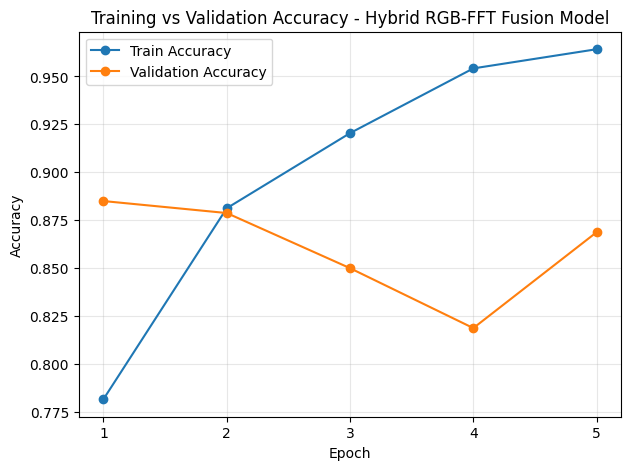

In [36]:
# ============================================================
# 23. Training and Validation Accuracy Curve
# ============================================================

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_accuracy"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy - Hybrid RGB-FFT Fusion Model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(epochs))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [37]:
# ============================================================
# 24. Save Hybrid Model Results
# ============================================================

results = {
    "model": ["Hybrid_RGB_FFT_Fusion"],
    "input_type": ["RGB + FFT_Magnitude"],
    "best_val_accuracy": [best_val_accuracy],
    "test_accuracy": [test_accuracy],
    "test_precision": [test_precision],
    "test_recall": [test_recall],
    "test_f1_score": [test_f1],
    "test_loss": [test_loss],
    "epochs": [NUM_EPOCHS],
    "training_time_minutes": [training_time / 60]
}

results_df = pd.DataFrame(results)

results_path = "/kaggle/working/hybrid_rgb_fft_fusion_results.csv"
results_df.to_csv(results_path, index=False)

print("Hybrid results saved successfully.")
print(results_df)

Hybrid results saved successfully.
                   model           input_type  best_val_accuracy  \
0  Hybrid_RGB_FFT_Fusion  RGB + FFT_Magnitude              0.885   

   test_accuracy  test_precision  test_recall  test_f1_score  test_loss  \
0         0.8425        0.832524       0.8575       0.844828   0.319707   

   epochs  training_time_minutes  
0       5              25.598851  


In [38]:
# ============================================================
# 25. Save Hybrid Training History
# ============================================================

history_df = pd.DataFrame(history)
history_df["epoch"] = range(1, NUM_EPOCHS + 1)

history_path = "/kaggle/working/hybrid_rgb_fft_training_history.csv"
history_df.to_csv(history_path, index=False)

print("Hybrid training history saved successfully.")
print(history_df)

Hybrid training history saved successfully.
   train_loss  train_accuracy  val_loss  val_accuracy  epoch
0    0.452394        0.781667  0.302381       0.88500      1
1    0.290530        0.881250  0.297272       0.87875      2
2    0.204124        0.920417  0.362649       0.85000      3
3    0.124813        0.954167  0.573638       0.81875      4
4    0.106233        0.964167  0.414700       0.86875      5


# 10. Result Interpretation

The hybrid RGB-FFT fusion model achieved a best validation accuracy of 88.50%.

This is much higher than the FFT-only baseline and very close to the RGB-only baseline.

## Key Observation

The FFT-only model overfitted heavily and achieved weak validation/test performance.  
However, when FFT features were used as a secondary modality alongside RGB features, the hybrid model recovered strong classification performance.

## Interpretation

This suggests that FFT information may contain useful complementary cues, but raw FFT magnitude spectra are not reliable enough as a standalone representation in this simplified setup.

The result is consistent with recent spatial-frequency fusion research, where frequency information is usually combined with spatial features instead of replacing them completely.

## Limitation

The simple RGB+FFT fusion model did not clearly outperform the RGB-only baseline.  
This suggests that stronger frequency feature engineering may be required.

## Next Step

The next experiment will add a radial energy distribution branch inspired by FreqCross.

This branch summarizes how FFT energy is distributed from low to high frequencies and may capture more stable frequency-domain patterns than raw FFT images alone.